<a href="https://colab.research.google.com/github/AndersonLems/data_fuel_python/blob/main/data_fuel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [197]:
import pandas as pd
import requests
import time
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np


In [167]:
sheets = ["Reg Gasoline (below RON 95) USD", "Diesel USD"]
dfs = []
rate =5.27

for sheet in sheets:
    print(f"\n--- ABA: {sheet} ---")

    df = pd.read_excel(
        "/content/data/Global_Fuel_Prices_Database.xlsx",
        sheet_name=sheet,
        header=None
    )

    df.columns = df.iloc[0]
    df = df[1:].reset_index(drop=True)

    column_fixed = []
    column_date = []

    for col in df.columns:
        data_teste = pd.to_datetime(col, errors="coerce")

        if pd.isna(data_teste):
            column_fixed.append(col)
        else:
            column_date.append(col)

    print("Colunas fixas:", column_fixed[:10])
    print("Qtd colunas de data:", len(column_date))

    df_long = df.melt(
        id_vars=column_fixed,
        value_vars=column_date,
        var_name="date",
        value_name="price"
    )

    df_long["date"] = pd.to_datetime(df_long["date"], errors="coerce")
    df_long["price"] = pd.to_numeric(df_long["price"], errors="coerce")

    df_long = df_long.dropna(subset=["price"])

    df_long["fuel_type"] = sheet

    dfs.append(df_long)

df_final = pd.concat(dfs, ignore_index=True)

print(df_final.head())
print(df_final.columns)
print(df_final.shape)


--- ABA: Reg Gasoline (below RON 95) USD ---
Colunas fixas: ['Regular Gasoline (LCU/liter)', 'Country', 'Country Code', 'Original Units', 'Converted Units', 'Default MAP (1 to show)']
Qtd colunas de data: 113

--- ABA: Diesel USD ---
Colunas fixas: ['Diesel (LCU/liter)', 'Country', 'Country Code', 'Original Units', 'Converted Units', 'Default MAP (1 to show)']
Qtd colunas de data: 113
                      Regular Gasoline (LCU/liter)     Country Country Code  \
0                       Algeria (Regular Gasoline)     Algeria          DZA   
1          Argentina (Nafta (common) up to 92 Ron)   Argentina          ARG   
2  Argentina (Nafta (super) between 92 and 95 Ron)   Argentina          ARG   
3      Azerbaijan (Gasoline 92)  - Regulated Price  Azerbaijan          AZE   
4                            Bahrain (Gasoline 91)     Bahrain          BHR   

   Original Units Converted Units Default MAP (1 to show)       date  \
0       DZD/liter       USD/liter                       1 2015-1

In [168]:
df_analysis = df_final[
    ["Country", "Country Code", "date", "price", "fuel_type"]
].copy()

df_analysis.columns = [
    "pais",
    "codigo_pais",
    "data",
    "preco (USD)",
    "tipo_combustivel"
]

df_analysis["tipo_combustivel"] = df_analysis["tipo_combustivel"].replace({
    "Reg Gasoline (below RON 95) USD": "Gasolina",
    "Diesel USD": "Diesel"
})

print(df_analysis.head())
print(df_analysis.shape)


         pais codigo_pais       data  preco (USD) tipo_combustivel
0     Algeria         DZA 2015-12-01     0.197986         Gasolina
1   Argentina         ARG 2015-12-01     0.975524         Gasolina
2   Argentina         ARG 2015-12-01     1.247089         Gasolina
3  Azerbaijan         AZE 2015-12-01     0.561622         Gasolina
4     Bahrain         BHR 2015-12-01     0.212226         Gasolina
(30165, 5)


In [169]:
# Dados do ano atual
ano_atual = df_analysis["data"].dt.year.max()

df_ano_atual = df_analysis[
    df_analysis["data"].dt.year == ano_atual
].copy()


In [170]:
df_gasolina_ano_atual = df_ano_atual[
    df_ano_atual["tipo_combustivel"] == "Gasolina"
].copy()

ranking_gasolina_atual = (
    df_gasolina_ano_atual.groupby("pais")["preco (USD)"]
    .mean ()
    .sort_values(ascending=False)
    .reset_index()
)

preco_brasil_atual = (
    df_gasolina_ano_atual[df_gasolina_ano_atual["pais"] == "Brazil"]["preco (USD)"]
    .mean()
)

top_10 = ranking_gasolina_atual.head(10)


posicao_brasil_atual = ranking_gasolina_atual[
    ranking_gasolina_atual["pais"] == "Brazil"
].index[0] + 1

print(f"\nBrasil está na posição: {posicao_brasil_atual}")
print(f"Preço médio Brasil: {preco_brasil_atual:.2f} USD/L")


Brasil está na posição: 25
Preço médio Brasil: 1.06 USD/L


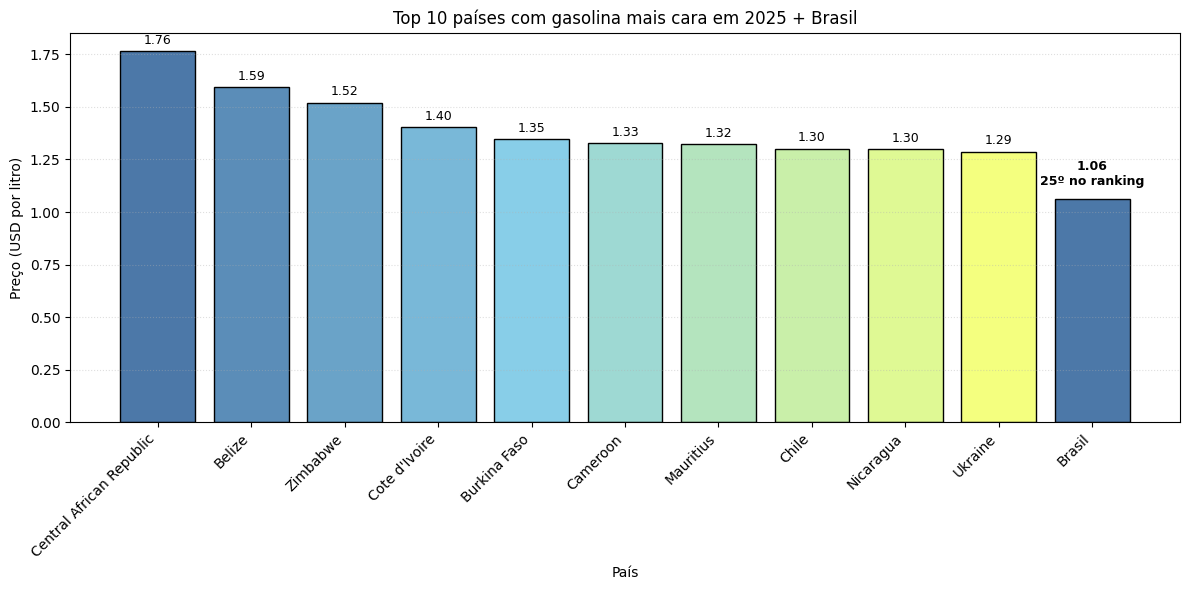

In [171]:
brasil = ranking_gasolina_atual[ranking_gasolina_atual["pais"] == "Brazil"].copy()
if "Brazil" not in top_10["pais"].values:
    grafico = pd.concat([top_10, brasil], ignore_index=True)
else:
    grafico = top_10.copy()

grafico = grafico.sort_values("preco (USD)", ascending=False).reset_index(drop=True)
posicao_brasil_atual = ranking_gasolina_atual[ranking_gasolina_atual["pais"] == "Brazil"].index[0] + 1

labels = ["Brasil" if pais == "Brazil" else pais for pais in grafico["pais"]]

colors = [
    "#4c78a8", "#5b8db8", "#6aa3c8", "#79b8d8", "#88cee8",
    "#9ed9d3", "#b4e4be", "#c9efa9", "#dff994", "#f4ff7f"
]

plt.figure(figsize=(12, 6))
barras = plt.bar(labels, grafico["preco (USD)"], color=colors, edgecolor="black")

for i, barra in enumerate(barras):
    altura = barra.get_height()

    if grafico.iloc[i]["pais"] == "Brazil":
        plt.text(
            barra.get_x() + barra.get_width() / 2,
            altura + 0.05,
            f"{altura:.2f}\n{posicao_brasil_atual}º no ranking",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )
    else:
        plt.text(
            barra.get_x() + barra.get_width() / 2,
            altura + 0.02,
            f"{altura:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.title(f"Top 10 países com gasolina mais cara em {ano_atual} + Brasil")
plt.xlabel("País")
plt.ylabel("Preço (USD por litro)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle=":", alpha=0.4)

plt.tight_layout()
plt.show()

In [172]:
paises_por_regiao = {
    "América do Norte": [
        "United States",
        "Canada",
        "Mexico",
        "Greenland"
    ],

    "América Central": [
        "Costa Rica",
        "Guatemala",
        "Panama",
        "Dominican Republic"
    ],

    "América Latina": [
        "Brazil",
        "Argentina",
        "Chile",
        "Peru",
        "Venezuela, RB"
    ],

    "Europa / Eurásia": [
        "Ukraine",
        "Russian Federation",
        "Azerbaijan",
        "Kazakhstan"
    ],

    "Oriente Médio": [
        "United Arab Emirates",
        "Saudi Arabia",
        "Qatar",
        "Oman"
    ],

    "Ásia": [
        "China",
        "Japan",
        "Indonesia",
        "Thailand"
    ],

    "África": [
        "South Africa",
        "Egypt, Arab Rep.",
        "Ghana",
        "Ethiopia"
    ],

    "Oceania": [
        "New Zealand",
        "Fiji",
        "Cabo Verde"
    ]
}

df_gasolina = df_analysis[
    df_analysis["tipo_combustivel"] == "Gasolina"
].copy()


todos_paises = []

for lista in paises_por_regiao.values():
    todos_paises.extend(lista)

todos_paises = list(set(todos_paises))

df_comparacao = (
    df_gasolina[df_gasolina["pais"].isin(todos_paises)]
    .groupby(["data", "pais"], as_index=False)["preco (USD)"]
    .mean()
)

print(df_comparacao.head(10))
print(df_comparacao.columns)
print(df_comparacao["data"].min(), df_comparacao["data"].max())

        data              pais  preco (USD)
0 2015-12-01         Argentina     1.111307
1 2015-12-01        Azerbaijan     0.561622
2 2015-12-01            Brazil     0.967017
3 2015-12-01             Chile     1.010419
4 2015-12-01             China     0.850572
5 2015-12-01        Costa Rica     0.697979
6 2015-12-01  Egypt, Arab Rep.     0.268362
7 2015-12-01              Fiji     0.992231
8 2015-12-01         Greenland     0.881582
9 2015-12-01         Guatemala     0.677820
Index(['data', 'pais', 'preco (USD)'], dtype='object')
2015-12-01 00:00:00 2025-03-01 00:00:00


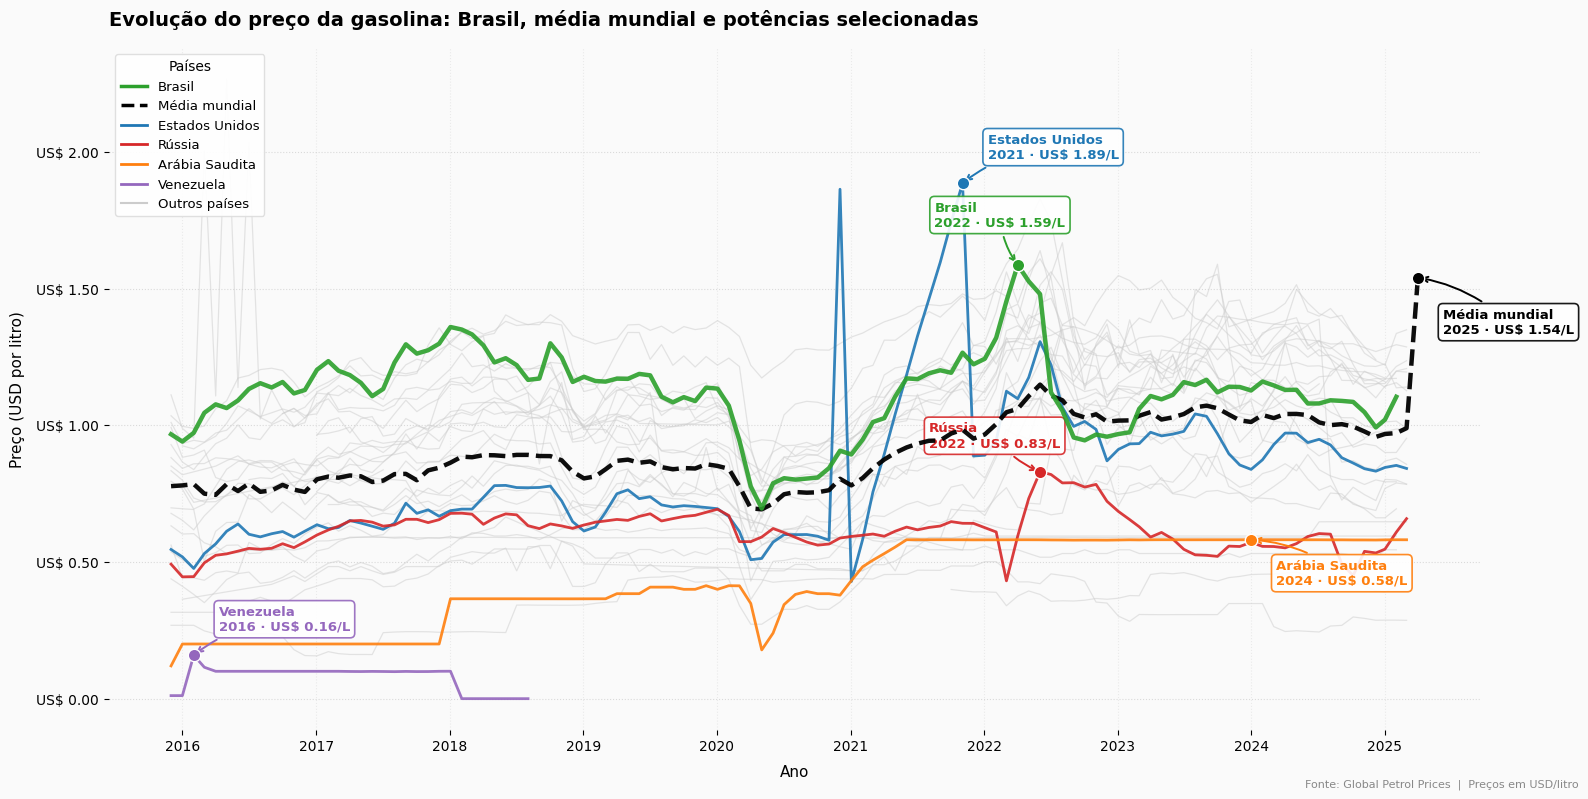

In [173]:
CORES = {
    "Brazil":             "#2ca02c",
    "United States":      "#1f77b4",
    "Russian Federation": "#d62728",
    "Saudi Arabia":       "#ff7f0e",
    "Venezuela, RB":      "#9467bd",
    "Média mundial":      "#000000",
}

TRADUCOES = {
    "Brazil":             "Brasil",
    "United States":      "Estados Unidos",
    "Russian Federation": "Rússia",
    "Saudi Arabia":       "Arábia Saudita",
    "Venezuela, RB":      "Venezuela",
    "Média mundial":      "Média mundial",
}

PAISES_DESTAQUE = set(CORES.keys())

df_gasolina_limpo = df_gasolina.copy()
df_gasolina_limpo = df_gasolina_limpo[
    (df_gasolina_limpo["preco (USD)"] > 0) &
    (df_gasolina_limpo["preco (USD)"] <= 5)
].copy()

df_media_mundial = (
    df_gasolina_limpo.groupby("data", as_index=False)["preco (USD)"].mean()
)
df_media_mundial["pais"] = "Média mundial"

df_plot = pd.concat([df_comparacao, df_media_mundial], ignore_index=True)
df_plot["pais_exibicao"] = df_plot["pais"].map(TRADUCOES).fillna(df_plot["pais"])

fig, ax = plt.subplots(figsize=(16, 8))
fig.patch.set_facecolor("#fafafa")
ax.set_facecolor("#fafafa")

for pais in df_plot["pais"].unique():
    if pais in PAISES_DESTAQUE:
        continue
    dados = df_plot[df_plot["pais"] == pais].sort_values("data")
    ax.plot(
        dados["data"], dados["preco (USD)"],
        color="#cccccc", linewidth=0.9, alpha=0.5, zorder=1
    )

for pais, cor in CORES.items():
    dados = df_plot[df_plot["pais"] == pais].sort_values("data")
    if dados.empty:
        continue

    lw = 3.2 if pais in ("Brazil", "Média mundial") else 2.0
    z  = 5   if pais == "Brazil" else (4 if pais == "Média mundial" else 3)

    if pais == "Média mundial":
        ax.plot(dados["data"], dados["preco (USD)"],
                color=cor, linewidth=lw, linestyle="--", alpha=0.95, zorder=z)
    else:
        ax.plot(dados["data"], dados["preco (USD)"],
                color=cor, linewidth=lw, alpha=0.9, zorder=z)

def anotar_pico(ax, df_plot, pais, cor, xytext):
    dados = df_plot[df_plot["pais"] == pais].sort_values("data")
    if dados.empty:
        return
    idx  = dados["preco (USD)"].idxmax()
    pico = dados.loc[idx]
    nome = TRADUCOES.get(pais, pais)

    ax.scatter(pico["data"], pico["preco (USD)"],
               color=cor, s=80, zorder=10, edgecolors="white", linewidths=1)
    ax.annotate(
        f'{nome}\n{pico["data"].year} · US$ {pico["preco (USD)"]:.2f}/L',
        xy=(pico["data"], pico["preco (USD)"]),
        xytext=xytext,
        textcoords="offset points",
        fontsize=9.5,
        color=cor,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
                  edgecolor=cor, linewidth=1.2, alpha=0.9),
        arrowprops=dict(arrowstyle="->", color=cor, lw=1.4,
                        connectionstyle="arc3,rad=0.15")
    )

anotar_pico(ax, df_plot, "Brazil",             CORES["Brazil"],             xytext=(-60,  28))
anotar_pico(ax, df_plot, "Média mundial",       CORES["Média mundial"],      xytext=( 18, -40))
anotar_pico(ax, df_plot, "United States",       CORES["United States"],      xytext=( 18,  18))
anotar_pico(ax, df_plot, "Russian Federation",  CORES["Russian Federation"], xytext=(-80,  18))
anotar_pico(ax, df_plot, "Saudi Arabia",        CORES["Saudi Arabia"],       xytext=( 18, -32))
anotar_pico(ax, df_plot, "Venezuela, RB",       CORES["Venezuela, RB"],      xytext=( 18,  18))

legend_items = [
    Line2D([0], [0], color=CORES["Brazil"],             lw=2.5, label="Brasil"),
    Line2D([0], [0], color=CORES["Média mundial"],      lw=2.5, linestyle="--", label="Média mundial"),
    Line2D([0], [0], color=CORES["United States"],      lw=2,   label="Estados Unidos"),
    Line2D([0], [0], color=CORES["Russian Federation"], lw=2,   label="Rússia"),
    Line2D([0], [0], color=CORES["Saudi Arabia"],       lw=2,   label="Arábia Saudita"),
    Line2D([0], [0], color=CORES["Venezuela, RB"],      lw=2,   label="Venezuela"),
    Line2D([0], [0], color="#cccccc",                   lw=1.5, label="Outros países"),
]
ax.legend(
    handles=legend_items,
    loc="upper left",
    fontsize=9.5,
    framealpha=0.92,
    edgecolor="#dddddd",
    facecolor="white",
    title="Países",
    title_fontsize=10,
)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.tick_params(axis="x", rotation=0, labelsize=10)
ax.tick_params(axis="y", labelsize=10)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"US$ {v:.2f}"))
ax.set_xlabel("Ano", fontsize=11, labelpad=8)
ax.set_ylabel("Preço (USD por litro)", fontsize=11, labelpad=8)

ax.grid(True, which="major", axis="y", linestyle=":", alpha=0.4, color="#aaaaaa")
ax.grid(True, which="major", axis="x", linestyle=":", alpha=0.2, color="#aaaaaa")
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(
    "Evolução do preço da gasolina: Brasil, média mundial e potências selecionadas",
    fontsize=14, fontweight="bold", pad=16, loc="left"
)
fig.text(
    0.99, 0.01,
    "Fonte: Global Petrol Prices  |  Preços em USD/litro",
    ha="right", fontsize=8, color="#888888"
)

plt.tight_layout()
plt.show()


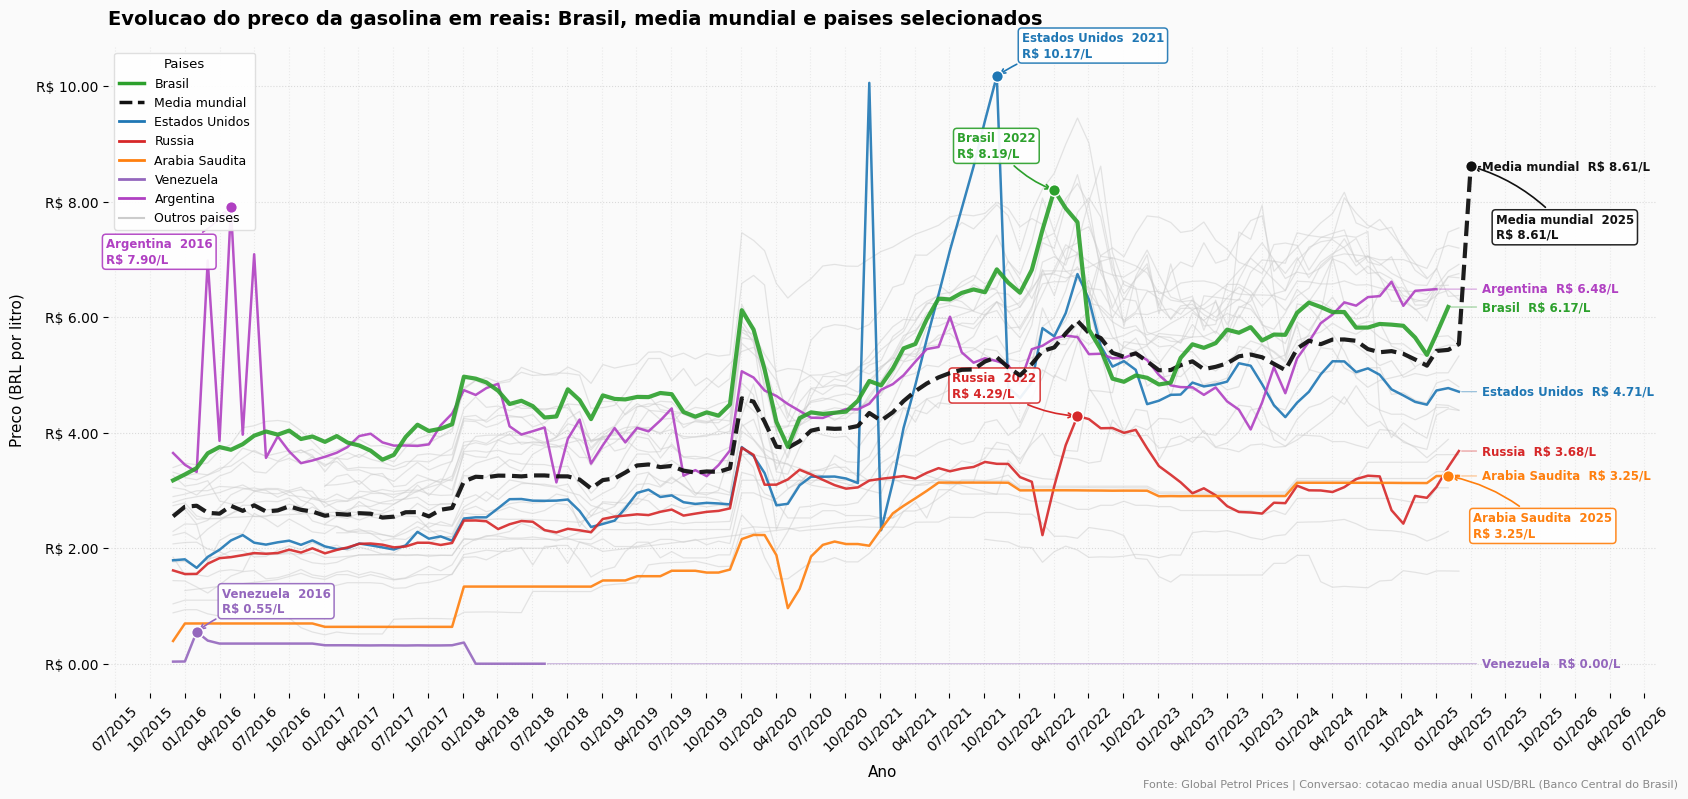

In [174]:
CAMBIO_ANUAL = {
    2015: 3.282,
    2016: 3.484,
    2017: 3.192,
    2018: 3.655,
    2019: 3.945,
    2020: 5.396,
    2021: 5.394,
    2022: 5.165,
    2023: 4.994,
    2024: 5.389,
    2025: 5.592,
}

CORES = {
    "Brazil":             "#2ca02c",
    "United States":      "#1f77b4",
    "Russian Federation": "#d62728",
    "Saudi Arabia":       "#ff7f0e",
    "Venezuela, RB":      "#9467bd",
    "Argentina":          "#b040c2",
    "Media mundial":      "#111111",
}

TRADUCOES = {
    "Brazil":             "Brasil",
    "United States":      "Estados Unidos",
    "Russian Federation": "Russia",
    "Saudi Arabia":       "Arabia Saudita",
    "Venezuela, RB":      "Venezuela",
    "Argentina":          "Argentina",
    "Media mundial":      "Media mundial",
}

# Offsets verticais manuais para evitar sobreposicao dos labels finais (em pontos)
LABEL_OFFSET_Y = {
    "Brazil":             10,
    "Media mundial":      28,
    "United States":     -18,
    "Russian Federation": 10,
    "Saudi Arabia":      -14,
    "Venezuela, RB":     -28,
    "Argentina":          26,
}

# Offsets para anotacoes de pico
PICO_OFFSET = {
    "Brazil":             (-70,  32),
    "Media mundial":      ( 18, -44),
    "United States":      ( 18,  22),
    "Russian Federation": (-90,  22),
    "Saudi Arabia":       ( 18, -36),
    "Venezuela, RB":      ( 18,  22),
    "Argentina":          (-90, -32),
}

PAISES_DESTAQUE = set(CORES.keys())

def usd_para_brl(df):
    df = df.copy()
    df["ano"] = df["data"].dt.year
    df["cambio"] = df["ano"].map(CAMBIO_ANUAL)
    df["preco (BRL)"] = df["preco (USD)"] * df["cambio"]
    return df

df_gasolina_limpo = df_gasolina.copy()
df_gasolina_limpo = df_gasolina_limpo[
    (df_gasolina_limpo["preco (USD)"] > 0) &
    (df_gasolina_limpo["preco (USD)"] <= 5)
].copy()
df_gasolina_limpo = usd_para_brl(df_gasolina_limpo)

df_media_mundial = (
    df_gasolina_limpo.groupby("data", as_index=False)["preco (BRL)"].mean()
)
df_media_mundial["pais"] = "Media mundial"

df_comparacao_brl = usd_para_brl(df_comparacao)
df_plot = pd.concat([df_comparacao_brl, df_media_mundial], ignore_index=True)
df_plot["pais_exibicao"] = df_plot["pais"].map(TRADUCOES).fillna(df_plot["pais"])

fig, ax = plt.subplots(figsize=(17, 8))
fig.patch.set_facecolor("#fafafa")
ax.set_facecolor("#fafafa")

# Paises de fundo
for pais in df_plot["pais"].unique():
    if pais in PAISES_DESTAQUE:
        continue
    dados = df_plot[df_plot["pais"] == pais].sort_values("data")
    if "preco (BRL)" not in dados.columns:
        continue
    ax.plot(dados["data"], dados["preco (BRL)"],
            color="#cccccc", linewidth=0.9, alpha=0.5, zorder=1)

# Paises em destaque
for pais, cor in CORES.items():
    dados = df_plot[df_plot["pais"] == pais].sort_values("data")
    if dados.empty or "preco (BRL)" not in dados.columns:
        continue

    lw = 3.0 if pais in ("Brazil", "Media mundial") else 1.8
    z  = 5   if pais == "Brazil" else (4 if pais == "Media mundial" else 3)

    if pais == "Media mundial":
        ax.plot(dados["data"], dados["preco (BRL)"],
                color=cor, linewidth=lw, linestyle="--", alpha=0.95, zorder=z)
    else:
        ax.plot(dados["data"], dados["preco (BRL)"],
                color=cor, linewidth=lw, alpha=0.9, zorder=z)

# Labels do ultimo preco — posicionados com offset manual
x_max = df_plot["data"].max()

for pais, cor in CORES.items():
    dados = df_plot[df_plot["pais"] == pais].sort_values("data")
    if dados.empty or "preco (BRL)" not in dados.columns:
        continue

    ultimo = dados.iloc[-1]
    nome   = TRADUCOES.get(pais, pais)
    dy     = LABEL_OFFSET_Y.get(pais, 0)

    ax.annotate(
        f"{nome}  R$ {ultimo['preco (BRL)']:.2f}/L",
        xy=(ultimo["data"], ultimo["preco (BRL)"]),
        xytext=(x_max + pd.DateOffset(days=30), ultimo["preco (BRL)"]),
        textcoords="data",
        fontsize=8.5,
        color=cor,
        fontweight="bold",
        va="center",
        annotation_clip=False,
        xycoords="data",
        arrowprops=dict(arrowstyle="-", color=cor, lw=0.8, alpha=0.5),
    )

# Anotacoes de pico
def anotar_pico(ax, df_plot, pais, cor):
    dados = df_plot[df_plot["pais"] == pais].sort_values("data")
    if dados.empty or "preco (BRL)" not in dados.columns:
        return
    idx  = dados["preco (BRL)"].idxmax()
    pico = dados.loc[idx]
    nome = TRADUCOES.get(pais, pais)
    xytext = PICO_OFFSET.get(pais, (18, 18))

    ax.scatter(pico["data"], pico["preco (BRL)"],
               color=cor, s=70, zorder=10, edgecolors="white", linewidths=1)
    ax.annotate(
        f'{nome}  {pico["data"].year}\nR$ {pico["preco (BRL)"]:.2f}/L',
        xy=(pico["data"], pico["preco (BRL)"]),
        xytext=xytext,
        textcoords="offset points",
        fontsize=8.5,
        color=cor,
        fontweight="bold",
        va="center",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                  edgecolor=cor, linewidth=1.1, alpha=0.92),
        arrowprops=dict(arrowstyle="->", color=cor, lw=1.2,
                        connectionstyle="arc3,rad=0.15")
    )

for pais in CORES:
    anotar_pico(ax, df_plot, pais, CORES[pais])

# Legenda
legend_items = [
    Line2D([0], [0], color=CORES["Brazil"],             lw=2.5, label="Brasil"),
    Line2D([0], [0], color=CORES["Media mundial"],      lw=2.5, linestyle="--", label="Media mundial"),
    Line2D([0], [0], color=CORES["United States"],      lw=2,   label="Estados Unidos"),
    Line2D([0], [0], color=CORES["Russian Federation"], lw=2,   label="Russia"),
    Line2D([0], [0], color=CORES["Saudi Arabia"],       lw=2,   label="Arabia Saudita"),
    Line2D([0], [0], color=CORES["Venezuela, RB"],      lw=2,   label="Venezuela"),
    Line2D([0], [0], color=CORES["Argentina"],          lw=2,   label="Argentina"),
    Line2D([0], [0], color="#cccccc",                   lw=1.5, label="Outros paises"),
]
ax.legend(
    handles=legend_items,
    loc="upper left",
    fontsize=9,
    framealpha=0.92,
    edgecolor="#dddddd",
    facecolor="white",
    title="Paises",
    title_fontsize=9.5,
)

ax.set_xlim(right=x_max + pd.DateOffset(months=16))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%Y"))
ax.tick_params(axis="x", rotation=45, labelsize=10)
ax.tick_params(axis="y", labelsize=10)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"R$ {v:.2f}"))
ax.set_xlabel("Ano", fontsize=11, labelpad=8)
ax.set_ylabel("Preco (BRL por litro)", fontsize=11, labelpad=8)

ax.grid(True, which="major", axis="y", linestyle=":", alpha=0.4, color="#aaaaaa")
ax.grid(True, which="major", axis="x", linestyle=":", alpha=0.2, color="#aaaaaa")
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(
    "Evolucao do preco da gasolina em reais: Brasil, media mundial e paises selecionados",
    fontsize=14, fontweight="bold", pad=16, loc="left"
)
fig.text(
    0.99, 0.01,
    "Fonte: Global Petrol Prices | Conversao: cotacao media anual USD/BRL (Banco Central do Brasil)",
    ha="right", fontsize=8, color="#888888"
)

plt.tight_layout()
plt.show()


In [176]:
def estilo_base(fig, ax):
    fig.patch.set_facecolor("#fafafa")
    ax.set_facecolor("#fafafa")
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(True, which="major", axis="y", linestyle=":", alpha=0.4, color="#aaaaaa")
    ax.grid(True, which="major", axis="x", linestyle=":", alpha=0.2, color="#aaaaaa")
    ax.set_axisbelow(True)

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%Y"))
    ax.tick_params(axis="x", rotation=45, labelsize=10)
    ax.tick_params(axis="y", labelsize=10)

    ax.axvline(ultima_data, color="#bbbbbb", linewidth=1, linestyle=":", zorder=1)

Estimativa dez/2026: R$ 6.19/L


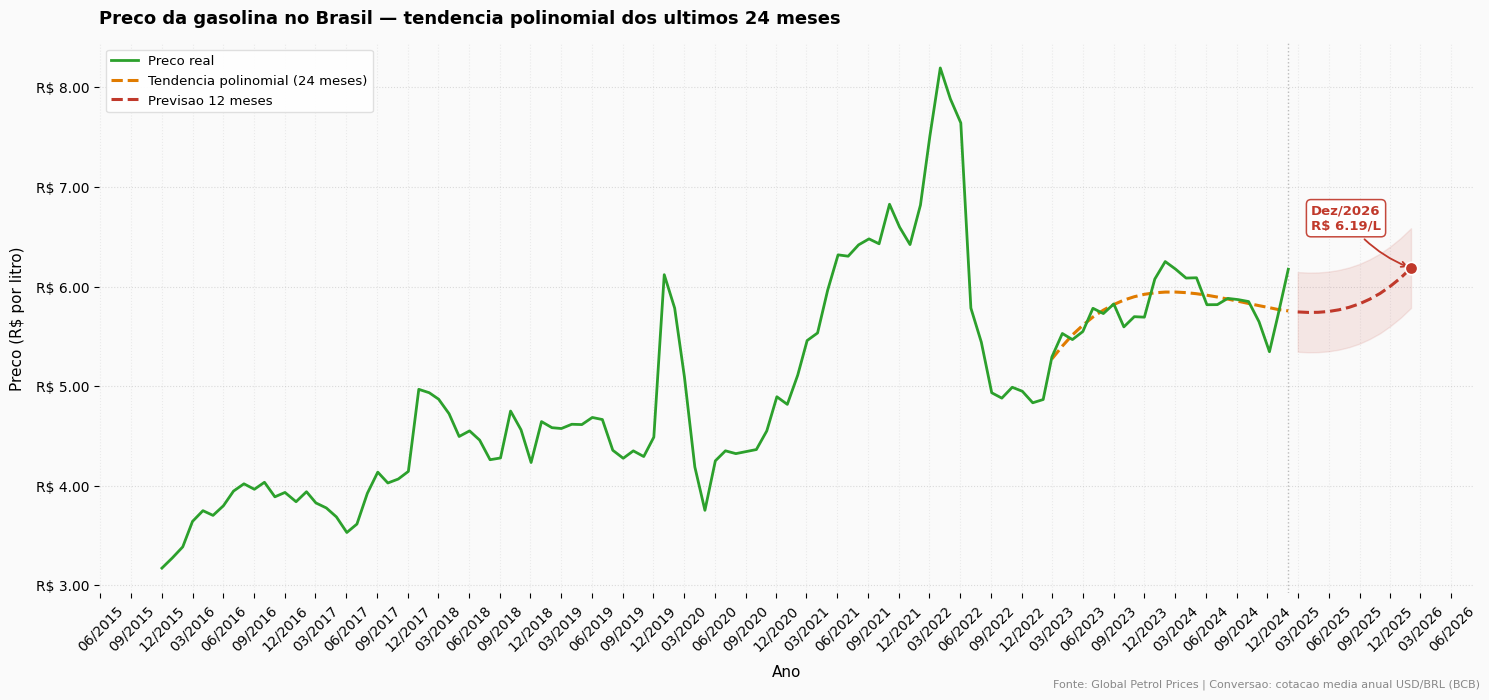

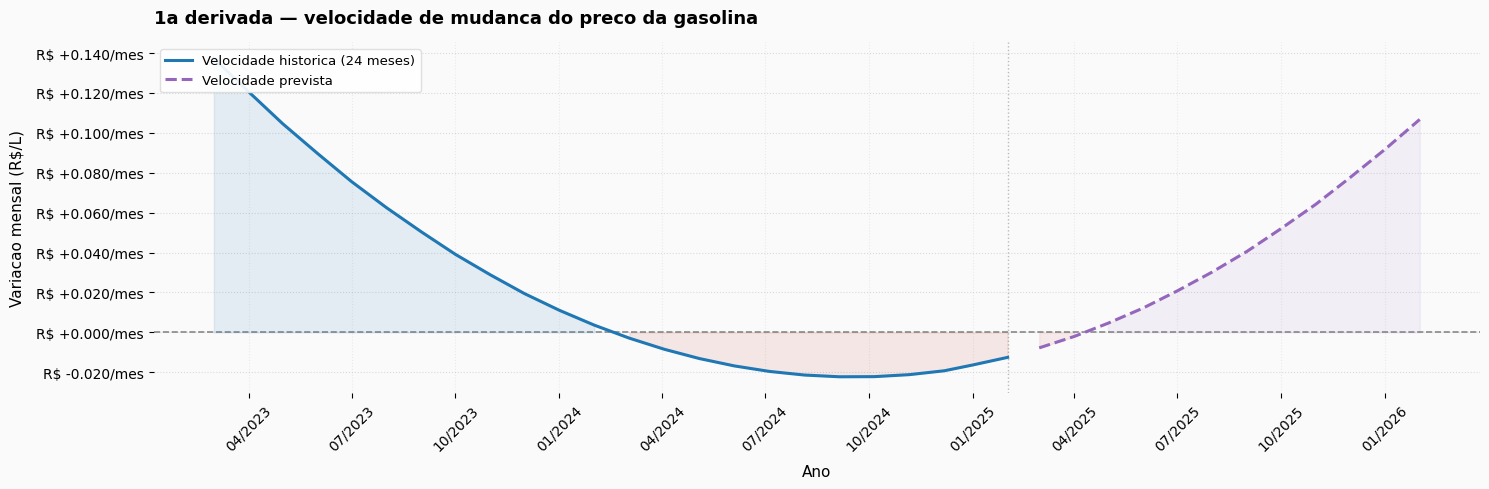

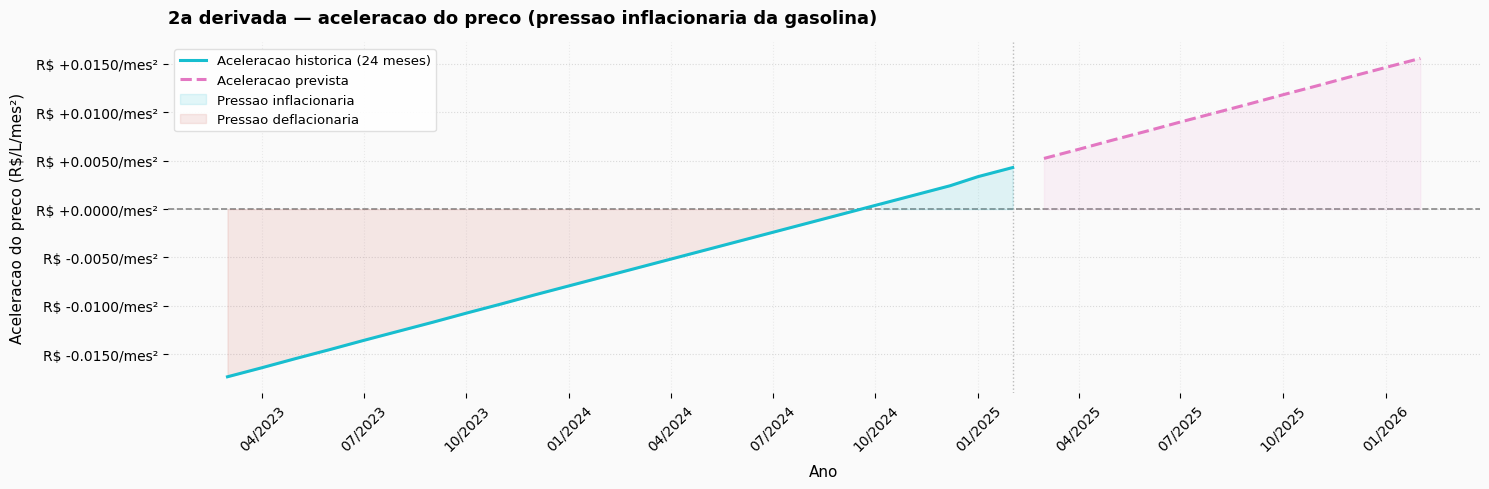

In [177]:
df_recente = df_brasil.tail(24).copy()
df_recente["indice_local"] = range(len(df_recente))

grau    = 3
modelo  = make_pipeline(PolynomialFeatures(degree=grau, include_bias=False), LinearRegression())
X_rec   = df_recente[["indice_local"]]
y_rec   = df_recente["preco_rs"]
modelo.fit(X_rec, y_rec)

df_recente["previsao"] = modelo.predict(X_rec)

ultimo_indice_local = df_recente["indice_local"].max()
ultima_data         = df_recente["data"].max()
datas_futuras       = pd.date_range(start=ultima_data + pd.offsets.MonthBegin(1), periods=12, freq="MS")

futuro = pd.DataFrame({
    "data":         datas_futuras,
    "indice_local": np.arange(ultimo_indice_local + 1, ultimo_indice_local + 13)
})
futuro["previsao"] = modelo.predict(futuro[["indice_local"]])

coef  = modelo.named_steps["linearregression"].coef_
a, b, c = coef[2], coef[1], coef[0]

primeira  = lambda x: 3*a*(x**2) + 2*b*x + c
segunda   = lambda x: 6*a*x + 2*b

df_recente["deriv1"] = primeira(df_recente["indice_local"])
df_recente["deriv2"] = segunda(df_recente["indice_local"])
futuro["deriv1"]     = primeira(futuro["indice_local"])
futuro["deriv2"]     = segunda(futuro["indice_local"])

valor_dez_2026 = futuro["previsao"].iloc[-1]
print(f"Estimativa dez/2026: R$ {valor_dez_2026:.2f}/L")

COR_REAL  = "#2ca02c"
COR_TEND  = "#e07b00"
COR_PREV  = "#c0392b"
COR_D1_H  = "#1f77b4"
COR_D1_P  = "#9467bd"
COR_D2_H  = "#17becf"
COR_D2_P  = "#e377c2"

# Grafico 1 — Preco e tendencia dos 24 meses
fig1, ax1 = plt.subplots(figsize=(15, 7))
estilo_base(fig1, ax1)

ax1.plot(df_brasil["data"], df_brasil["preco_rs"],
         color=COR_REAL, linewidth=2.0, label="Preco real", zorder=3)
ax1.plot(df_recente["data"], df_recente["previsao"],
         color=COR_TEND, linewidth=2.2, linestyle="--", label="Tendencia polinomial (24 meses)", zorder=2)
ax1.plot(futuro["data"], futuro["previsao"],
         color=COR_PREV, linewidth=2.2, linestyle="--", label="Previsao 12 meses", zorder=2)
ax1.fill_between(futuro["data"],
                 futuro["previsao"] - 0.4, futuro["previsao"] + 0.4,
                 color=COR_PREV, alpha=0.10, zorder=1)

ax1.scatter(futuro["data"].iloc[-1], valor_dez_2026,
            color=COR_PREV, s=80, zorder=10, edgecolors="white", linewidths=1.2)
ax1.annotate(
    f"Dez/2026\nR$ {valor_dez_2026:.2f}/L",
    xy=(futuro["data"].iloc[-1], valor_dez_2026),
    xytext=(-72, 28), textcoords="offset points",
    fontsize=9.5, fontweight="bold", color=COR_PREV,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor=COR_PREV, linewidth=1.1, alpha=0.92),
    arrowprops=dict(arrowstyle="->", color=COR_PREV, lw=1.3, connectionstyle="arc3,rad=0.15")
)

ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"R$ {v:.2f}"))
ax1.set_xlabel("Ano", fontsize=11, labelpad=8)
ax1.set_ylabel("Preco (R$ por litro)", fontsize=11, labelpad=8)
ax1.legend(fontsize=9.5, framealpha=0.92, edgecolor="#dddddd", facecolor="white", loc="upper left")
ax1.set_title("Preco da gasolina no Brasil — tendencia polinomial dos ultimos 24 meses",
              fontsize=13, fontweight="bold", pad=14, loc="left")
fig1.text(0.99, 0.01,
          "Fonte: Global Petrol Prices | Conversao: cotacao media anual USD/BRL (BCB)",
          ha="right", fontsize=8, color="#888888")
plt.tight_layout()
plt.show()

# Grafico 2 — Primeira derivada (velocidade de mudanca)
fig2, ax2 = plt.subplots(figsize=(15, 5))
estilo_base(fig2, ax2)

ax2.plot(df_recente["data"], df_recente["deriv1"],
         color=COR_D1_H, linewidth=2.2, label="Velocidade historica (24 meses)")
ax2.plot(futuro["data"], futuro["deriv1"],
         color=COR_D1_P, linewidth=2.2, linestyle="--", label="Velocidade prevista")
ax2.axhline(0, color="#888888", linewidth=1.2, linestyle="--", zorder=1)
ax2.fill_between(df_recente["data"], df_recente["deriv1"], 0,
                 where=df_recente["deriv1"] > 0, color=COR_D1_H, alpha=0.10)
ax2.fill_between(df_recente["data"], df_recente["deriv1"], 0,
                 where=df_recente["deriv1"] < 0, color=COR_PREV, alpha=0.10)
ax2.fill_between(futuro["data"], futuro["deriv1"], 0,
                 where=futuro["deriv1"] > 0, color=COR_D1_P, alpha=0.08)
ax2.fill_between(futuro["data"], futuro["deriv1"], 0,
                 where=futuro["deriv1"] < 0, color=COR_PREV, alpha=0.08)

ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"R$ {v:+.3f}/mes"))
ax2.set_xlabel("Ano", fontsize=11, labelpad=8)
ax2.set_ylabel("Variacao mensal (R$/L)", fontsize=11, labelpad=8)
ax2.legend(fontsize=9.5, framealpha=0.92, edgecolor="#dddddd", facecolor="white", loc="upper left")
ax2.set_title("1a derivada — velocidade de mudanca do preco da gasolina",
              fontsize=13, fontweight="bold", pad=14, loc="left")
plt.tight_layout()
plt.show()

# Grafico 3 — Segunda derivada (aceleracao / pressao inflacionaria)
fig3, ax3 = plt.subplots(figsize=(15, 5))
estilo_base(fig3, ax3)

ax3.plot(df_recente["data"], df_recente["deriv2"],
         color=COR_D2_H, linewidth=2.2, label="Aceleracao historica (24 meses)")
ax3.plot(futuro["data"], futuro["deriv2"],
         color=COR_D2_P, linewidth=2.2, linestyle="--", label="Aceleracao prevista")
ax3.axhline(0, color="#888888", linewidth=1.2, linestyle="--", zorder=1)
ax3.fill_between(df_recente["data"], df_recente["deriv2"], 0,
                 where=df_recente["deriv2"] > 0, color=COR_D2_H, alpha=0.12,
                 label="Pressao inflacionaria")
ax3.fill_between(df_recente["data"], df_recente["deriv2"], 0,
                 where=df_recente["deriv2"] < 0, color=COR_PREV, alpha=0.10,
                 label="Pressao deflacionaria")
ax3.fill_between(futuro["data"], futuro["deriv2"], 0,
                 where=futuro["deriv2"] > 0, color=COR_D2_P, alpha=0.08)
ax3.fill_between(futuro["data"], futuro["deriv2"], 0,
                 where=futuro["deriv2"] < 0, color=COR_PREV, alpha=0.08)

ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"R$ {v:+.4f}/mes²"))
ax3.set_xlabel("Ano", fontsize=11, labelpad=8)
ax3.set_ylabel("Aceleracao do preco (R$/L/mes²)", fontsize=11, labelpad=8)
ax3.legend(fontsize=9.5, framealpha=0.92, edgecolor="#dddddd", facecolor="white", loc="upper left")
ax3.set_title("2a derivada — aceleracao do preco (pressao inflacionaria da gasolina)",
              fontsize=13, fontweight="bold", pad=14, loc="left")
plt.tight_layout()
plt.show()


In [180]:
df_cluster = (
    df_gasolina_limpo
    .groupby("pais")
    .agg(
        preco_medio=("preco (USD)", "mean"),
        volatilidade=("preco (USD)", "std"),
        preco_min=("preco (USD)", "min"),
        preco_max=("preco (USD)", "max")
    )
    .reset_index()
)

df_cluster["amplitude"] = df_cluster["preco_max"] - df_cluster["preco_min"]

df_temp = df_gasolina_limpo.sort_values(["pais", "data"]).copy()

primeiro_preco = df_temp.groupby("pais")["preco (USD)"].first()
ultimo_preco = df_temp.groupby("pais")["preco (USD)"].last()

variacao_total = (
    ((ultimo_preco / primeiro_preco) - 1) * 100
).reset_index()

variacao_total.columns = ["pais", "variacao_percentual_total"]

df_cluster = df_cluster.merge(variacao_total, on="pais", how="left")

df_cluster = df_cluster.dropna().copy()

print(df_cluster.isna().sum())
print(df_cluster.shape)

pais                         0
preco_medio                  0
volatilidade                 0
preco_min                    0
preco_max                    0
amplitude                    0
variacao_percentual_total    0
dtype: int64
(83, 7)


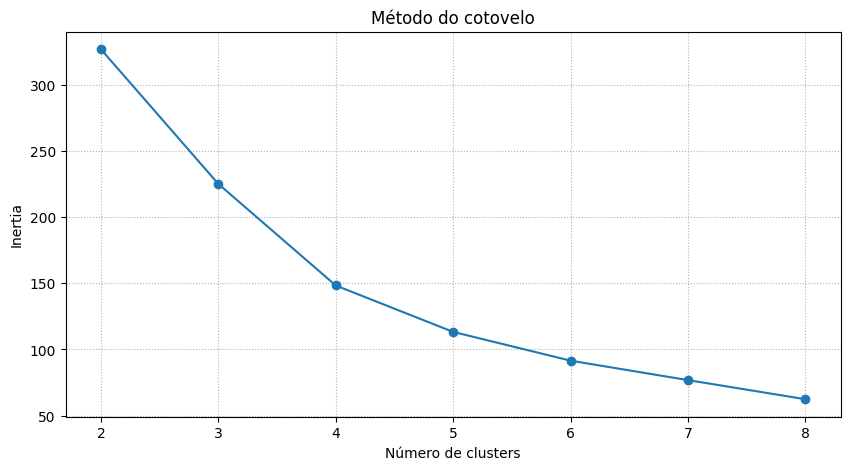

In [182]:
features = [
    "preco_medio",
    "volatilidade",
    "preco_min",
    "preco_max",
    "amplitude",
    "variacao_percentual_total"
]

X = df_cluster[features].copy()

# padronizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# método do cotovelo
inertia = []
ks = range(2, 9)

for k in ks:
    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    modelo.fit(X_scaled)
    inertia.append(modelo.inertia_)

plt.figure(figsize=(10,5))
plt.plot(list(ks), inertia, marker="o")
plt.title("Método do cotovelo")
plt.xlabel("Número de clusters")
plt.ylabel("Inertia")
plt.grid(True, linestyle=":")
plt.show()

In [191]:
k_final = 4

kmeans = KMeans(
    n_clusters=k_final,
    random_state=42,
    n_init=10
)

df_cluster["cluster"] = kmeans.fit_predict(X_scaled)

print(df_cluster["cluster"].value_counts())

perfil_clusters = (
    df_cluster.groupby("cluster")[features]
    .mean()
    .round(3)
)

print(perfil_clusters)

cluster_brasil = df_cluster.loc[
    df_cluster["pais"] == "Brazil",
    "cluster"
].iloc[0]

print("Cluster do Brasil:", cluster_brasil)

print(
    df_cluster[df_cluster["cluster"] == cluster_brasil]
    [["pais"] + features]
    .sort_values("preco_medio")
)

cluster
0    51
1    24
2     7
3     1
Name: count, dtype: int64
         preco_medio  volatilidade  preco_min  preco_max  amplitude  \
cluster                                                               
0              1.051         0.163      0.716      1.458      0.742   
1              0.494         0.071      0.356      0.650      0.294   
2              0.981         0.384      0.405      2.277      1.872   
3              1.301         0.422      0.006      1.800      1.794   

         variacao_percentual_total  
cluster                             
0                           28.305  
1                           39.148  
2                           15.344  
3                        25615.108  
Cluster do Brasil: 0
                        pais  preco_medio  volatilidade  preco_min  preco_max  \
76      United Arab Emirates     0.650522      0.180774   0.351212   1.197931   
71                  Thailand     0.704965      0.226558   0.195216   1.280642   
59                  P

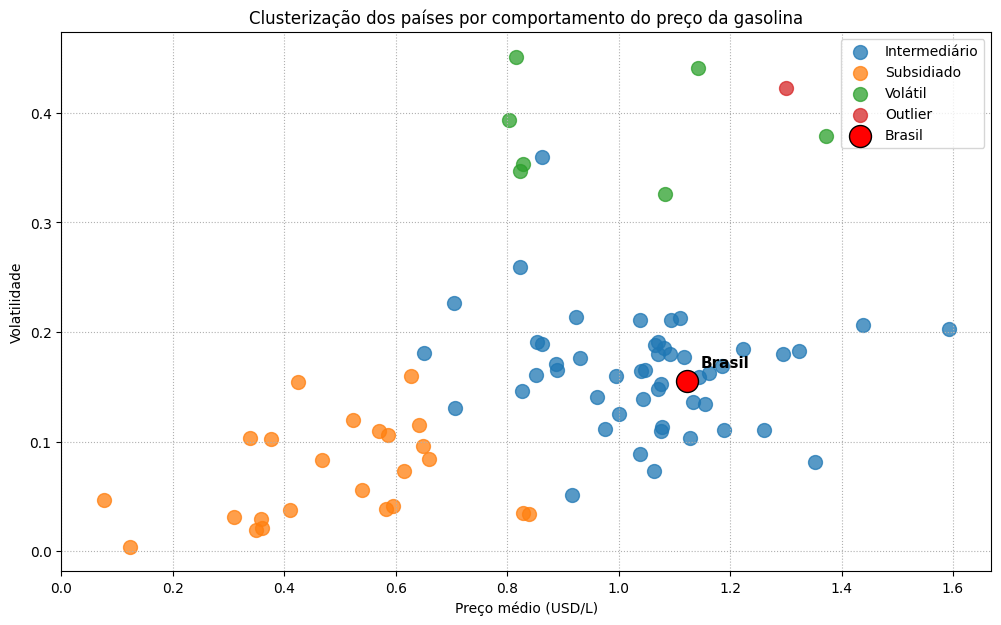

In [188]:
nomes_clusters = {
    0: "Intermediário",
    1: "Subsidiado",
    2: "Volátil",
    3: "Outlier"
}

df_cluster["nome_cluster"] = df_cluster["cluster"].map(nomes_clusters)

plt.figure(figsize=(12,7))

for cluster in sorted(df_cluster["cluster"].unique()):
    temp = df_cluster[df_cluster["cluster"] == cluster]

    plt.scatter(
        temp["preco_medio"],
        temp["volatilidade"],
        s=100,
        label=nomes_clusters[cluster],
        alpha=0.75
    )

# destacar Brasil
brasil = df_cluster[df_cluster["pais"] == "Brazil"]

plt.scatter(
    brasil["preco_medio"],
    brasil["volatilidade"],
    s=250,
    color="red",
    edgecolors="black",
    label="Brasil"
)

plt.annotate(
    "Brasil",
    xy=(brasil["preco_medio"].iloc[0], brasil["volatilidade"].iloc[0]),
    xytext=(10, 10),
    textcoords="offset points",
    fontsize=11,
    fontweight="bold"
)

plt.title("Clusterização dos países por comportamento do preço da gasolina")
plt.xlabel("Preço médio (USD/L)")
plt.ylabel("Volatilidade")
plt.grid(True, linestyle=":")
plt.legend()
plt.show()

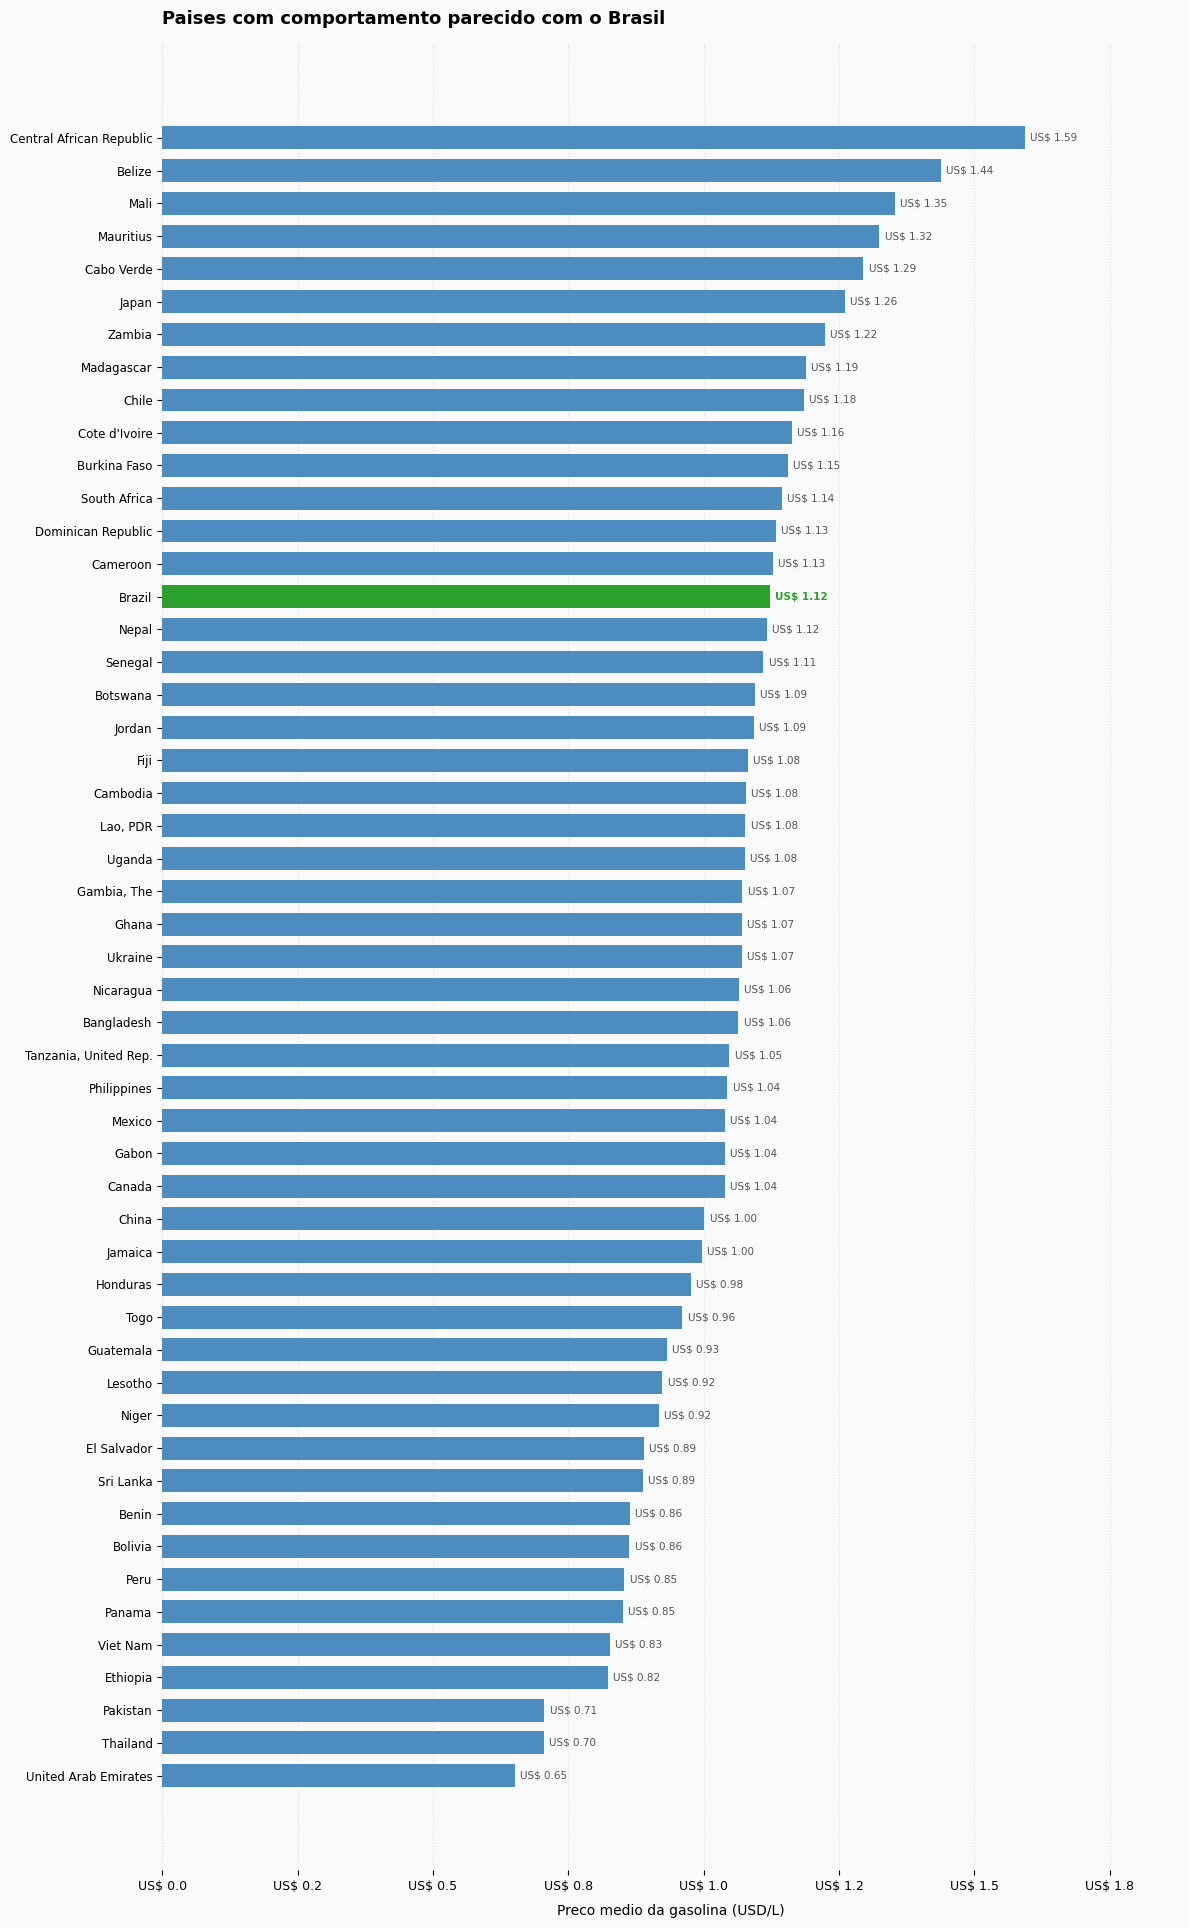

In [198]:

cluster_brasil = df_cluster.loc[df_cluster["pais"] == "Brazil", "cluster"].iloc[0]

df_brasil_cluster = (
    df_cluster[df_cluster["cluster"] == cluster_brasil]
    .sort_values("preco_medio")
    .copy()
)

n = len(df_brasil_cluster)
altura_por_barra = 0.38
fig_height = max(10, n * altura_por_barra)

fig, ax = plt.subplots(figsize=(12, fig_height))
fig.patch.set_facecolor("#fafafa")
ax.set_facecolor("#fafafa")

cores = ["#2ca02c" if pais == "Brazil" else "#4c8cbf" for pais in df_brasil_cluster["pais"]]

ax.barh(
    df_brasil_cluster["pais"],
    df_brasil_cluster["preco_medio"],
    color=cores,
    height=0.7,
    edgecolor="none",
)

for i, (pais, preco) in enumerate(zip(df_brasil_cluster["pais"], df_brasil_cluster["preco_medio"])):
    cor_texto = "#2ca02c" if pais == "Brazil" else "#555555"
    peso      = "bold"    if pais == "Brazil" else "normal"
    ax.text(preco + 0.01, i, f"US$ {preco:.2f}", va="center", fontsize=7.5,
            color=cor_texto, fontweight=peso)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(axis="x", linestyle=":", alpha=0.35, color="#aaaaaa")
ax.set_axisbelow(True)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"US$ {v:.1f}"))
ax.tick_params(axis="y", labelsize=8.5)
ax.tick_params(axis="x", labelsize=9)
ax.set_xlim(right=df_brasil_cluster["preco_medio"].max() * 1.18)

ax.set_title("Paises com comportamento parecido com o Brasil",
             fontsize=13, fontweight="bold", pad=14, loc="left")
ax.set_xlabel("Preco medio da gasolina (USD/L)", fontsize=10, labelpad=8)
ax.set_ylabel("")

plt.tight_layout()
plt.show()